# The Fed Model: Are Equities Cheap or Expensive Relative to Bonds?

**Cordell Tanny, CFA, FRM, FDP**  
[ctanny.ca](https://ctanny.ca) | [github.com/ctanny/quant-finance-snippets](https://github.com/ctanny/quant-finance-snippets)

---

One of the oldest and most debated tools in equity valuation is the Fed model, a framework that compares the earnings yield on equities to the yield on long-term government bonds. The idea is intuitive: investors allocating between stocks and bonds should care about the relative yield each asset offers. When equities offer a higher yield than bonds, stocks look attractive on a relative basis. When bonds yield more than equities, the calculus shifts.

The model was popularized by economist Ed Yardeni in the late 1990s, who noted that the Federal Reserve appeared to use this relationship implicitly in its Humphrey-Hawkins reports. The name stuck even though the Fed never officially endorsed it.

The calculation is straightforward:

**Fed Model Spread = Earnings Yield - 10-Year Treasury Yield**

where Earnings Yield = 1 / (Trailing Twelve Month Price-to-Earnings Ratio)

A positive spread means equities are offering more yield than bonds. A negative spread means bonds are offering more yield than equities.

In this notebook we will:
1. Build the Fed model from scratch using publicly available data
2. Chart the spread historically with recession periods highlighted
3. Look at the current reading and what it is telling us today
4. Overlay inflation to understand the context the model operates in
5. Discuss the model's limitations honestly, because no valuation tool is complete on its own

> **Data note**: The S&P 500 trailing PE ratio data is sourced from [macrotrends.net](https://www.macrotrends.net/2577/sp-500-pe-ratio-price-to-earnings-chart) and stored locally as `data/sp500_historical_pe.csv`. The 10-year Treasury yield and CPI data are pulled directly from FRED using `pandas_datareader`. No API key is required for FRED data.


## 1. Imports and Parameters

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas_datareader.data as web
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ── Parameters ─────────────────────────────────────────────────────────────
# Adjust these to change the analysis window in one place
START_DATE = '1993-01-01'
END_DATE   = '2026-04-30'

# Path to the PE ratio CSV file
# Download from: https://www.macrotrends.net/2577/sp-500-pe-ratio-price-to-earnings-chart
# Upload the P/E data to Colab and ensure the file name matches
PE_FILE = '/content/S&P-500-Price-Earnings-Ratio.csv'  # change this if needed

## 2. Load PE Ratio Data and Calculate Earnings Yield

The earnings yield is the inverse of the price-to-earnings ratio, expressed as a percentage. It represents the annual earnings generated per dollar invested in the index, making it directly comparable to a bond yield.

We use trailing twelve month earnings throughout. This is the original formulation and avoids the forward earnings estimation error that comes with using analyst forecasts. Shiller's CAPE (cyclically adjusted PE) is a different animal: it smooths earnings over 10 years to reduce cyclicality. That is a valid approach for long-term valuation but it changes the signal, so we stick with TTM here.

In [12]:
# Load PE ratio data
df_pe = pd.read_csv(PE_FILE, index_col=0, header=0, parse_dates=True)

# Calculate earnings yield: reciprocal of PE ratio, expressed as percentage
# Earnings Yield = (1 / PE) * 100
df_ey = (1 / df_pe['S&P 500 PE Ratio']).mul(100).round(2)  # Ensure the column name matches your CSV
df_ey = df_ey.to_frame(name='Earnings Yield (%)')

# Resample to month-end to align with FRED data
df_ey = df_ey.resample('ME').last()
df_ey = df_ey[df_ey.index >= START_DATE]

print(f"PE data loaded: {df_ey.index[0].date()} to {df_ey.index[-1].date()}")
print(f"Current earnings yield: {df_ey['Earnings Yield (%)'].iloc[-1]:.2f}%")
df_ey.tail()

PE data loaded: 1993-01-31 to 2026-04-30
Current earnings yield: 3.18%


,Earnings Yield (%)
DateTime,
2025-12-31,3.38
2026-01-31,3.40
2026-02-28,3.52
2026-03-31,3.36
2026-04-30,3.18


## 3. Download 10-Year Treasury Yield from FRED

We pull the 10-year constant maturity Treasury yield directly from FRED using `pandas_datareader`. No API key required.

The series code is `DGS10` — the daily 10-year Treasury constant maturity rate. We resample to month-end to align with the PE data.

In [13]:
# Download 10-year Treasury yield from FRED
# DGS10: 10-Year Treasury Constant Maturity Rate (daily)
df_10yr = web.DataReader('DGS10', 'fred', START_DATE, END_DATE)
df_10yr.columns = ['10-Year Treasury Yield (%)']

# Resample to month-end
df_10yr = df_10yr.resample('ME').last()

print(f"Treasury data loaded: {df_10yr.index[0].date()} to {df_10yr.index[-1].date()}")
print(f"Current 10-year yield: {df_10yr['10-Year Treasury Yield (%)'].iloc[-1]:.2f}%")
df_10yr.tail()

Treasury data loaded: 1993-01-31 to 2026-04-30
Current 10-year yield: 4.40%


,10-Year Treasury Yield (%)
DATE,
2025-12-31,4.18
2026-01-31,4.26
2026-02-28,3.97
2026-03-31,4.30
2026-04-30,4.40


## 4. Download Recession Periods from FRED

FRED provides a binary recession indicator series (`USREC`) where 1 = recession and 0 = expansion. We use this to add recession shading to the charts, which is essential context for any macroeconomic indicator.

In [14]:
# Download US recession indicator from FRED
# USREC: 1 during recessions, 0 otherwise
df_rec = web.DataReader('USREC', 'fred', '1980-01-01', END_DATE)
df_rec.columns = ['recession']


def get_recession_periods(rec_series):
    """
    Extract recession start and end dates from a binary recession indicator.
    Returns a list of (start_date, end_date) tuples.
    """
    periods = []
    in_recession = False
    start = None

    for date, val in rec_series.items():
        if val == 1 and not in_recession:
            in_recession = True
            start = date
        elif val == 0 and in_recession:
            in_recession = False
            periods.append((start, date))

    # Handle case where data ends during a recession
    if in_recession:
        periods.append((start, rec_series.index[-1]))

    return periods


def add_recession_bands(ax, recession_periods, alpha=0.15, color='#CC0000'):
    """
    Add shaded recession bands to a matplotlib axis.
    Color defaults to red at low alpha for subtlety.
    """
    for start, end in recession_periods:
        ax.axvspan(start, end, alpha=alpha, color=color, zorder=0)


recessions = get_recession_periods(df_rec['recession'])
print(f"Recession periods identified: {len(recessions)}")
for s, e in recessions:
    print(f"  {s.date()} to {e.date()}")

Recession periods identified: 6
  1980-02-01 to 1980-08-01
  1981-08-01 to 1982-12-01
  1990-08-01 to 1991-04-01
  2001-04-01 to 2001-12-01
  2008-01-01 to 2009-07-01
  2020-03-01 to 2020-05-01


## 5. Calculate the Fed Model Spread

In [15]:
# Merge earnings yield and treasury yield
df = pd.concat([df_ey, df_10yr], axis=1).dropna()
df = df[df.index >= START_DATE]

# Fed model spread: positive = equities cheap relative to bonds
#                   negative = bonds cheap relative to equities
df['Fed Model Spread (%)'] = df['Earnings Yield (%)'] - df['10-Year Treasury Yield (%)']

# Summary statistics
current   = df['Fed Model Spread (%)'].iloc[-1]
hist_mean = df['Fed Model Spread (%)'].mean()
hist_std  = df['Fed Model Spread (%)'].std()
z_score   = (current - hist_mean) / hist_std

print(f"Fed Model Spread Summary ({df.index[0].date()} to {df.index[-1].date()})")
print("=" * 55)
print(f"Current earnings yield    : {df['Earnings Yield (%)'].iloc[-1]:.2f}%")
print(f"Current 10-year yield     : {df['10-Year Treasury Yield (%)'].iloc[-1]:.2f}%")
print(f"Current Fed model spread  : {current:.2f}%")
print(f"Historical mean spread    : {hist_mean:.2f}%")
print(f"Historical std deviation  : {hist_std:.2f}%")
print(f"Current z-score           : {z_score:.2f}")
print(f"\nInterpretation: ", end='')
if current > 0:
    print(f"Equities offer {current:.2f}% more yield than bonds (equities relatively attractive)")
else:
    print(f"Bonds offer {abs(current):.2f}% more yield than equities (bonds relatively attractive)")

Fed Model Spread Summary (1993-01-31 to 2026-04-30)
Current earnings yield    : 3.18%
Current 10-year yield     : 4.40%
Current Fed model spread  : -1.22%
Historical mean spread    : 0.56%
Historical std deviation  : 2.02%
Current z-score           : -0.88

Interpretation: Bonds offer 1.22% more yield than equities (bonds relatively attractive)


## 6. The Fed Model Chart

The chart below shows the Fed model spread since 1990 with recession periods shaded in red. A few things to look for:

- The **late 1990s tech bubble**: earnings yields collapsed as valuations soared, pushing the spread deeply negative. Bonds were offering far more yield than equities at the peak.
- **The post-2008 era**: the spread turned sharply positive as earnings yields recovered and Treasury yields were pushed to historic lows by quantitative easing. This environment made equities look very attractive on a relative basis for over a decade.
- **The 2022 rate shock**: rapidly rising Treasury yields compressed the spread significantly. For the first time in years, bonds began to offer competitive yields relative to equities.
- **Today**: the current reading tells us where we stand relative to that history.

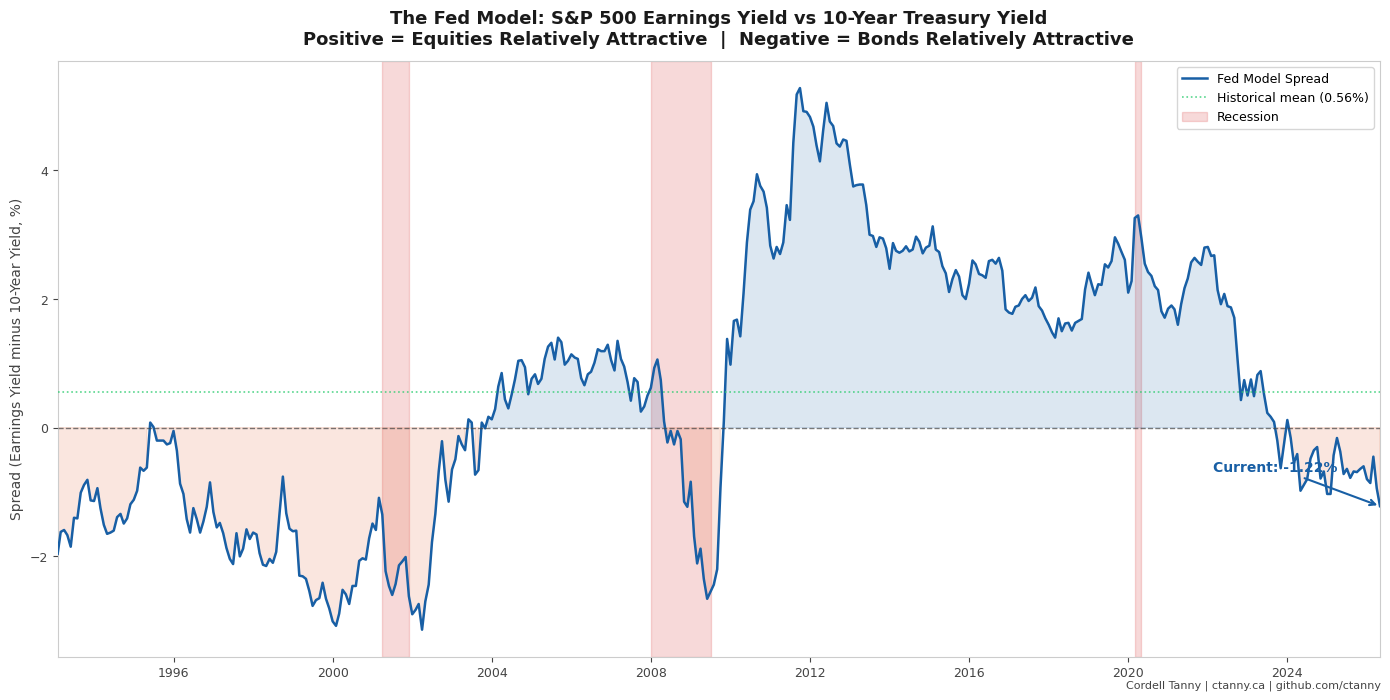

In [17]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Plot the spread
ax.plot(df.index, df['Fed Model Spread (%)'],
        color='#185FA5', linewidth=1.8, label='Fed Model Spread', zorder=3)

# Fill positive and negative areas differently
ax.fill_between(df.index, df['Fed Model Spread (%)'], 0,
                where=df['Fed Model Spread (%)'] >= 0,
                color='#185FA5', alpha=0.15, zorder=2)
ax.fill_between(df.index, df['Fed Model Spread (%)'], 0,
                where=df['Fed Model Spread (%)'] < 0,
                color='#E05C2A', alpha=0.15, zorder=2)

# Zero line
ax.axhline(0, color='#444444', linewidth=1, linestyle='--', alpha=0.7, zorder=3)

# Historical mean
ax.axhline(hist_mean, color='#2ECC71', linewidth=1.2,
           linestyle=':', alpha=0.8, label=f'Historical mean ({hist_mean:.2f}%)', zorder=3)

# Current value annotation
ax.annotate(
    f'Current: {current:.2f}%',
    xy=(df.index[-1], current),
    xytext=(-120, 25),
    textcoords='offset points',
    fontsize=10, color='#185FA5', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#185FA5', lw=1.5)
)

# Recession bands
add_recession_bands(ax, recessions)

# Formatting
ax.set_title('The Fed Model: S&P 500 Earnings Yield vs 10-Year Treasury Yield\n'
             'Positive = Equities Relatively Attractive  |  Negative = Bonds Relatively Attractive',
             fontsize=13, fontweight='bold', color='#1a1a1a', pad=12)
ax.set_ylabel('Spread (Earnings Yield minus 10-Year Yield, %)',
              fontsize=10, color='#444444')
ax.set_xlabel('', fontsize=10)
ax.tick_params(colors='#444444', labelsize=9)
for sp in ax.spines.values():
    sp.set_edgecolor('#cccccc')

# Legend
recession_patch = mpatches.Patch(color='#CC0000', alpha=0.15, label='Recession')
handles, labels = ax.get_legend_handles_labels()
handles.append(recession_patch)
labels.append('Recession')
ax.legend(handles, labels, fontsize=9, frameon=True,
          facecolor='white', edgecolor='#cccccc')

plt.figtext(0.99, 0.01,
            'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#444444', fontsize=8)

ax.set_xlim(df.index[0], df.index[-1])
plt.tight_layout()
plt.savefig('fed_model_spread.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

## 7. Where Are We Today?

The current reading needs to be interpreted in context. The z-score tells us how far the current spread is from its historical average, expressed in standard deviations. A z-score above +1 suggests equities look unusually attractive relative to bonds by historical standards. A z-score below -1 suggests the opposite.

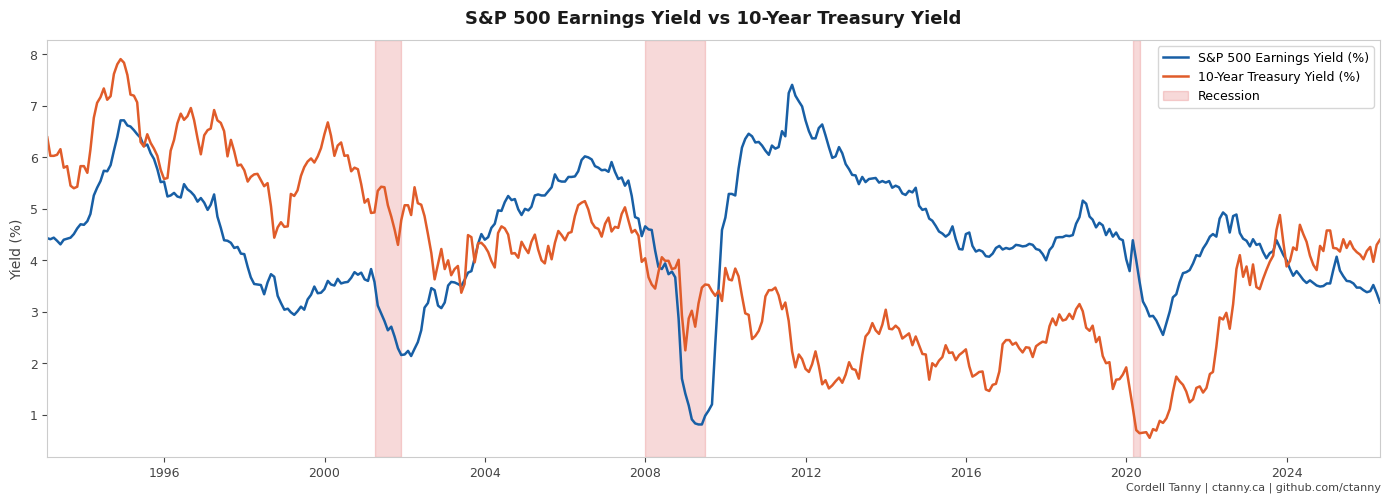


Current Snapshot
Earnings yield   : 3.18%
10-year yield    : 4.40%
Spread           : -1.22%
Historical mean  : 0.56%
Z-score          : -0.88 standard deviations from mean


In [18]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Plot both yields
ax.plot(df.index, df['Earnings Yield (%)'],
        color='#185FA5', linewidth=1.8, label='S&P 500 Earnings Yield (%)')
ax.plot(df.index, df['10-Year Treasury Yield (%)'],
        color='#E05C2A', linewidth=1.8, label='10-Year Treasury Yield (%)')

# Recession bands
add_recession_bands(ax, recessions)

ax.set_title('S&P 500 Earnings Yield vs 10-Year Treasury Yield',
             fontsize=13, fontweight='bold', color='#1a1a1a', pad=12)
ax.set_ylabel('Yield (%)', fontsize=10, color='#444444')
ax.tick_params(colors='#444444', labelsize=9)
for sp in ax.spines.values():
    sp.set_edgecolor('#cccccc')

recession_patch = mpatches.Patch(color='#CC0000', alpha=0.15, label='Recession')
handles, labels = ax.get_legend_handles_labels()
handles.append(recession_patch)
labels.append('Recession')
ax.legend(handles, labels, fontsize=9, frameon=True,
          facecolor='white', edgecolor='#cccccc')

plt.figtext(0.99, 0.01,
            'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#444444', fontsize=8)
plt.tight_layout()
ax.set_xlim(df.index[0], df.index[-1])
plt.savefig('fed_model_yields.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nCurrent Snapshot")
print("=" * 40)
print(f"Earnings yield   : {df['Earnings Yield (%)'].iloc[-1]:.2f}%")
print(f"10-year yield    : {df['10-Year Treasury Yield (%)'].iloc[-1]:.2f}%")
print(f"Spread           : {current:.2f}%")
print(f"Historical mean  : {hist_mean:.2f}%")
print(f"Z-score          : {z_score:.2f} standard deviations from mean")

## 8. The Inflation Context

The Fed model has a known limitation that becomes very clear when you overlay inflation: it compares a real yield (earnings yield) to a nominal yield (Treasury yield) without adjusting for inflation.

In a low inflation environment that mismatch does not matter much. But when inflation is high, the nominal Treasury yield embeds an inflation premium that the earnings yield does not reflect in the same way. This means the model can make equities look expensive during high inflation periods simply because Treasury yields are elevated, even if real yields are not particularly attractive.

The chart below overlays year-over-year CPI inflation on the Fed model spread. The relationship is informative and worth keeping in mind when interpreting any current reading.

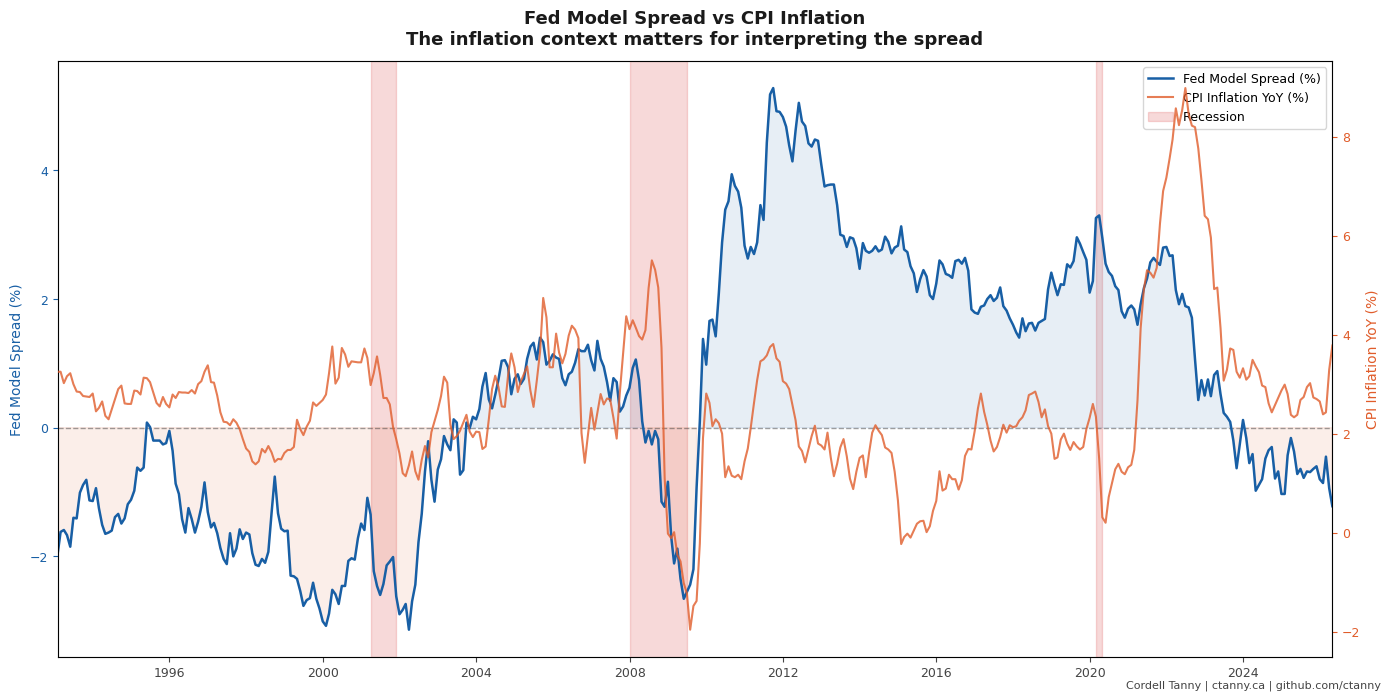

In [20]:
# Download CPI from FRED
df_cpi = web.DataReader('CPIAUCSL', 'fred', '1989-01-01', END_DATE)
df_cpi.columns = ['CPI']
df_cpi = df_cpi.resample('ME').last()

# Year-over-year percentage change
df_cpi['CPI YoY (%)'] = df_cpi['CPI'].pct_change(12).mul(100).round(2)
df_cpi = df_cpi[['CPI YoY (%)']].dropna()

# Merge with Fed model data
df_full = pd.concat([df, df_cpi], axis=1).dropna()
df_full = df_full[df_full.index >= START_DATE]

# Plot
fig, ax1 = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')

# Fed model spread on primary axis
ax1.plot(df_full.index, df_full['Fed Model Spread (%)'],
         color='#185FA5', linewidth=1.8, label='Fed Model Spread (%)', zorder=3)
ax1.fill_between(df_full.index, df_full['Fed Model Spread (%)'], 0,
                 where=df_full['Fed Model Spread (%)'] >= 0,
                 color='#185FA5', alpha=0.1, zorder=2)
ax1.fill_between(df_full.index, df_full['Fed Model Spread (%)'], 0,
                 where=df_full['Fed Model Spread (%)'] < 0,
                 color='#E05C2A', alpha=0.1, zorder=2)
ax1.axhline(0, color='#444444', linewidth=1, linestyle='--', alpha=0.5)
ax1.set_ylabel('Fed Model Spread (%)', fontsize=10, color='#185FA5')
ax1.tick_params(axis='y', colors='#185FA5', labelsize=9)
ax1.tick_params(axis='x', colors='#444444', labelsize=9)
for sp in ax1.spines.values():
    sp.set_edgecolor('#cccccc')

# CPI on secondary axis
ax2 = ax1.twinx()
ax2.set_facecolor('white')
ax2.plot(df_full.index, df_full['CPI YoY (%)'],
         color='#E05C2A', linewidth=1.5, alpha=0.8,
         label='CPI Inflation YoY (%)', zorder=3)
ax2.set_ylabel('CPI Inflation YoY (%)', fontsize=10, color='#E05C2A')
ax2.tick_params(axis='y', colors='#E05C2A', labelsize=9)
ax2.yaxis.grid(False)

# Recession bands
add_recession_bands(ax1, recessions)

ax1.set_title('Fed Model Spread vs CPI Inflation\n'
              'The inflation context matters for interpreting the spread',
              fontsize=13, fontweight='bold', color='#1a1a1a', pad=12)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
recession_patch  = mpatches.Patch(color='#CC0000', alpha=0.15, label='Recession')
ax1.legend(lines1 + lines2 + [recession_patch],
           labels1 + labels2 + ['Recession'],
           fontsize=9, frameon=True, facecolor='white', edgecolor='#cccccc')

plt.figtext(0.99, 0.01,
            'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#444444', fontsize=8)
ax1.set_xlim(df.index[0], df.index[-1])
plt.tight_layout()
plt.savefig('fed_model_inflation.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

## 9. Interpreting the Results

### Where We Stand Today

The current spread is -1.22%, meaning the 10-year Treasury is
offering 4.40% while the S&P 500 earnings yield sits at just
3.18%. On a pure Fed model basis, bonds are currently more
attractive than equities on a relative yield basis.

The historical mean spread since 1993 is +0.56%, so we are
sitting 1.78 percentage points below that average. The z-score
of -0.88 tells us we are nearly one standard deviation below
the long-run mean, which is notable but not at an extreme.
The late 1990s tech bubble pushed the spread to nearly -3%,
so there is historical precedent for things getting considerably
worse from here.

### What the Charts Are Telling Us

The second chart tells the clearest story. For most of the
period from 2010 to 2022, the earnings yield (blue) sat
comfortably above the Treasury yield (orange), which is what
drove the narrative that equities were the only game in town.
That relationship has now flipped, and it has flipped at a
time when inflation is still running above target and the bond
vigilantes are pushing yields higher.

The inflation overlay makes the current situation particularly
interesting. The last time the spread was this negative for
a sustained period was the late 1990s, and that coincided with
low and stable inflation. Today we have a negative spread in
an environment where inflation remains sticky and Treasury
yields are being pushed higher by fiscal concerns as much as
by monetary policy. That is a meaningfully different context.



## 10. Limitations of the Fed Model

No valuation tool should be used in isolation, and the Fed model has well-documented weaknesses that any practitioner should understand before relying on it.

**1. It compares a real yield to a nominal yield**  
Earnings yield is effectively a real return measure. The 10-year Treasury yield is nominal: it includes an inflation premium. In high inflation environments, this mismatch makes equities look more expensive than they actually are in real terms. Asness (2003) documented this problem extensively.

**2. It assumes a stable relationship between equities and bonds**  
The model implicitly assumes investors treat stocks and bonds as substitutes. This relationship breaks down during risk-off environments, deflation scares, or periods of quantitative easing where Treasury yields are policy-driven rather than market-driven.

**3. It uses backward-looking earnings**  
TTM earnings reflect the past, not the future. At cycle peaks, earnings are elevated and the spread looks more attractive than it should. At cycle troughs, earnings are depressed and the spread looks cheaper than it actually is.

**4. It has no predictive track record for short-term returns**  
Academic research has found that the Fed model has limited predictive power for equity returns over one to two year horizons. It works better as a long-term valuation framework than as a tactical timing signal.

**The bottom line**: the Fed model is a useful lens for thinking about relative value between equities and bonds, but it is one input among many. Use it to frame the conversation, not to make the decision.

---

**What comes next:**  
A natural follow-on is to look at the real Fed model: adjusting the Treasury yield for inflation expectations to make the comparison apples-to-apples. That is the subject of a future notebook.

---

*Cordell Tanny, CFA, FRM, FDP*  
[ctanny.ca](https://ctanny.ca) | [github.com/ctanny/quant-finance-snippets](https://github.com/ctanny/quant-finance-snippets)  
*Questions or ideas? Connect on LinkedIn.*